# SBI posterior parameter evaluation — cnn4e64-lipschitz-ae-reduced

Evaluates `exp_cnn4e64-lipschitz-ae-reduced_maf5_freeze-maf_1M`: same 4-phase AE pre-training as
`ae-reduced`, but the reduced encoder (Phase 2) uses a **soft spectral-norm ceiling** (C=2.0 per layer)
to enforce approximate Lipschitz continuity. Phases 3+4 freeze-warm then jointly train MAF conditioned
on the 128-dim Lipschitz embedding. 24-param theta (HR excluded).

**Point estimate comparison**: posterior mean vs GT — MAE, Median AE, MAPE  
**Posterior-specific**: 90% credible interval coverage per parameter  
**Lipschitz-specific**: spectral norm diagnostics on the trained encoder

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path(globals()['_dh'][0])  # kernel cwd = ~/cv-sbi/
sys.path.insert(0, str(ROOT))

from dataset import ReducedCVDataset, PARAM_KEYS_INFER, load_stats
from models import ReducedAutoencoderEncoder, LipschitzReducedAutoencoderEncoder  # both needed

In [2]:
RUN_NAME       = 'exp_cnn4e64-lipschitz-ae-reduced_maf5_freeze-maf_1M'
POSTERIOR_PATH = ROOT / f'outputs/{RUN_NAME}/posterior.pt'
STATS_PATH     = ROOT / 'norm_stats.json'
DATA_DIR       = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/test')
MANIFEST       = DATA_DIR.parent / 'manifest_test.json'

BATCH_SIZE          = 256
BATCH_IDX           = 0
N_POSTERIOR_SAMPLES = 1000

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## Load posterior and test data

In [3]:
posterior = torch.load(POSTERIOR_PATH, map_location=device, weights_only=False)
print('Posterior loaded:', type(posterior).__name__)

stats    = load_stats(STATS_PATH)
manifest = json.load(open(MANIFEST))

start   = BATCH_IDX * BATCH_SIZE
end     = start + BATCH_SIZE
entries = manifest['index'][start:end]
print(f'Test batch {BATCH_IDX}: sims {start}\u2013{end - 1}  ({len(entries)} entries)')

ds     = ReducedCVDataset(str(DATA_DIR), entries, stats)
loader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0)

all_theta, all_x = [], []
for theta_b, x_b in loader:
    all_theta.append(theta_b)
    all_x.append(x_b)
ds.close()

theta_gt = torch.cat(all_theta)  # (256, 24)
x_test   = torch.cat(all_x)      # (256, 809)
print(f'GT params: {theta_gt.shape}  observations: {x_test.shape}')

/home/sa4604/cv-sbi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Posterior loaded: DirectPosterior
Test batch 0: sims 0–255  (256 entries)
GT params: torch.Size([256, 24])  observations: torch.Size([256, 809])


## Autoencoder training comparison — Lipschitz vs regular

Phase 2 val MSE curves from the ae training logs, plus the summary from `ae_info.json`.
The Lipschitz encoder is trained on 1M sims; the regular encoder was also trained on 1M sims (as part of `exp_cnn4e64-ae-reduced_maf5_freeze-maf_1M`).
Higher phase 2 MSE for the Lipschitz run would indicate the spectral-norm constraint hurt reconstruction quality.

Metric                          Lipschitz      Regular
------------------------------------------------------
  Phase 1 best val MSE             0.0102       0.0103
  Phase 1 epochs                 150.0000     150.0000
  Phase 2 best val MSE             0.0868       0.0564
  Phase 2 epochs                 100.0000     100.0000


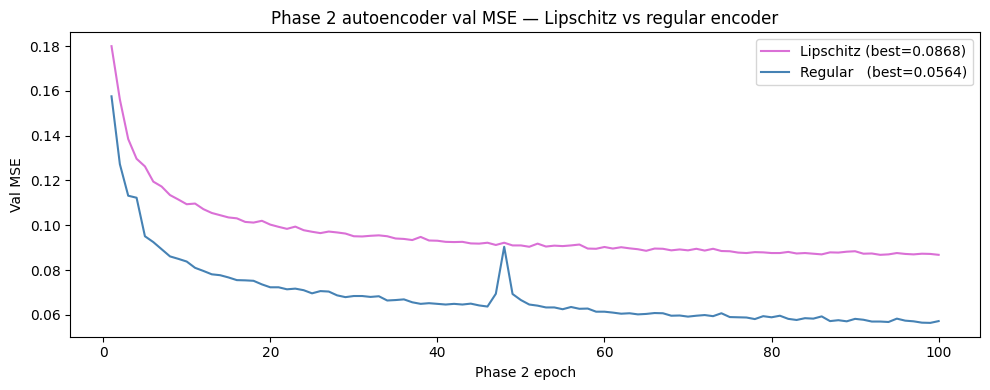

In [4]:
import re, glob

AE_RUN_LIP = 'exp_cnn4e64-lipschitz-ae-reduced_1M'
AE_RUN_REG = 'exp_cnn4e64-ae-reduced_maf5_freeze-maf_1M'

def parse_phase2_curve(run_name):
    """Parse (epoch, val_mse) for phase 2 from ae training log (latest log file)."""
    logs = sorted(glob.glob(str(ROOT / f'outputs/{run_name}/ae_*.log')))
    if not logs:
        raise FileNotFoundError(f'No ae log found under outputs/{run_name}/')
    epochs, val_mse = [], []
    in_phase2 = False
    for line in open(logs[-1]):
        if 'Phase 2: loading' in line:
            in_phase2 = True
        if 'Phase 2 done' in line:
            in_phase2 = False
        if in_phase2:
            m = re.search(r'epoch\s+(\d+)/\d+\s+train=[\d.]+\s+val=([\d.]+)', line)
            if m:
                epochs.append(int(m.group(1)))
                val_mse.append(float(m.group(2)))
    return epochs, val_mse

ep_lip, val_lip = parse_phase2_curve(AE_RUN_LIP)
ep_reg, val_reg = parse_phase2_curve(AE_RUN_REG)

# Summary from ae_info.json
info_lip = json.load(open(ROOT / f'outputs/{AE_RUN_LIP}/ae_info.json'))
info_reg = json.load(open(ROOT / f'outputs/{AE_RUN_REG}/ae_info.json'))

print(f"{'Metric':<28} {'Lipschitz':>12} {'Regular':>12}")
print('-' * 54)
for label, lv, rv in [
    ('Phase 1 best val MSE',  info_lip['training']['phase1_best_val'],    info_reg['training']['phase1_best_val']),
    ('Phase 1 epochs',        info_lip['training']['phase1_epochs_run'],   info_reg['training']['phase1_epochs_run']),
    ('Phase 2 best val MSE',  info_lip['training']['phase2_best_val'],     info_reg['training']['phase2_best_val']),
    ('Phase 2 epochs',        info_lip['training']['phase2_epochs_run'],   info_reg['training']['phase2_epochs_run']),
]:
    print(f"  {label:<26} {lv:>12.4f} {rv:>12.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ep_lip, val_lip, color='orchid',    linewidth=1.5, label=f'Lipschitz (best={min(val_lip):.4f})')
ax.plot(ep_reg, val_reg, color='steelblue', linewidth=1.5, label=f'Regular   (best={min(val_reg):.4f})')
ax.set_xlabel('Phase 2 epoch')
ax.set_ylabel('Val MSE')
ax.set_title('Phase 2 autoencoder val MSE — Lipschitz vs regular encoder')
ax.legend()
plt.tight_layout()
plt.show()

## Spectral norm comparison — σ₁ per layer (Lipschitz vs regular)

Parametrizations are baked into weights at save time, so σ₁ is computed here via power iteration.
All Lipschitz layers should be ≤ 2.0 (the ceiling); the regular encoder is unconstrained.
Note: the spectral norm of the baked weights reflects the value *after* joint fine-tuning with the flow —
it may drift slightly above C=2.0 if the flow pulled the encoder during NPE training (after parametrizations were no longer active).

Layer                            Lipschitz σ₁   Regular σ₁     ratio
--------------------------------------------------------------------
  cnn.0                                2.0010       4.8058    0.416x  ← AT CEILING
  cnn.2                                2.0001      19.3913    0.103x  ← AT CEILING
  cnn.4                                1.9989      29.4811    0.068x  ← AT CEILING
  cnn.6                                2.0004      33.9873    0.059x  ← AT CEILING
  scalar_projs.0                       2.0000       7.1934    0.278x  ← AT CEILING
  scalar_projs.1                       2.0000       8.1274    0.246x  ← AT CEILING
  scalar_projs.2                       2.0000       7.0938    0.282x  ← AT CEILING
  scalar_projs.3                       2.0000       7.7531    0.258x  ← AT CEILING
  scalar_projs.4                       2.0000       7.0236    0.285x  ← AT CEILING
  attn_pool                            1.4812       0.8455    1.752x
  proj                                 1.9962 

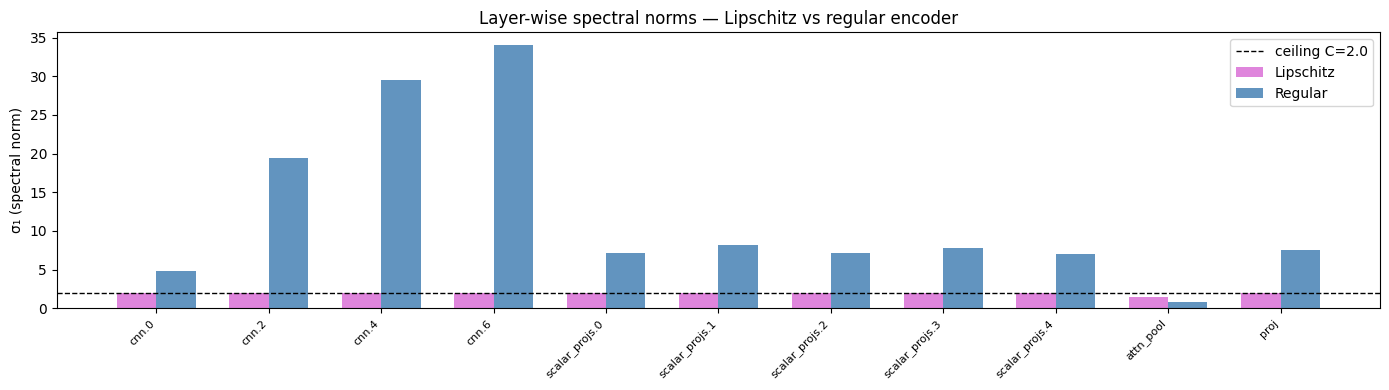

In [5]:
import torch.nn.functional as F

# Load both encoders here — reused by the ratio test cell below
enc_lip = posterior.posterior_estimator.embedding_net.to(device)
enc_lip.eval()

enc_reg = ReducedAutoencoderEncoder(latent_dim=128)
enc_reg.load_state_dict(torch.load(
    ROOT / f'outputs/{AE_RUN_REG}/phase2_encoder.pt', map_location='cpu'))
enc_reg = enc_reg.to(device)
enc_reg.eval()

def compute_spectral_norms(encoder, device='cpu'):
    """σ₁ per Conv1d/Linear layer via 20-step power iteration."""
    norms = {}
    for name, mod in encoder.named_modules():
        if not isinstance(mod, (torch.nn.Conv1d, torch.nn.Linear)): continue
        if not hasattr(mod, 'weight') or mod.weight is None: continue
        W = mod.weight.detach().to(device).reshape(mod.weight.shape[0], -1)
        u = F.normalize(torch.randn(W.shape[0], device=device), dim=0)
        for _ in range(20):
            v = F.normalize(W.t() @ u, dim=0)
            u = F.normalize(W @ v,   dim=0)
        norms[name] = (u @ (W @ v)).item()
    return norms

sn_lip = compute_spectral_norms(enc_lip, device=device)
sn_reg = compute_spectral_norms(enc_reg, device=device)
layers = list(sn_lip.keys())

print(f"{'Layer':<30} {'Lipschitz σ₁':>14} {'Regular σ₁':>12}  {'ratio':>8}")
print('-' * 68)
for k in layers:
    sl, sr = sn_lip[k], sn_reg[k]
    flag = '  ← AT CEILING' if sl >= 1.99 else ''
    print(f"  {k:<28} {sl:>14.4f} {sr:>12.4f}  {sl/sr:>7.3f}x{flag}")
print(f"\n  max Lipschitz σ₁: {max(sn_lip.values()):.4f}   max Regular σ₁: {max(sn_reg.values()):.4f}")

x_pos = np.arange(len(layers))
w = 0.35
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x_pos - w/2, [sn_lip[k] for k in layers], w, color='orchid',    alpha=0.85, label='Lipschitz')
ax.bar(x_pos + w/2, [sn_reg[k] for k in layers], w, color='steelblue', alpha=0.85, label='Regular')
ax.axhline(2.0, color='black', linestyle='--', linewidth=1, label='ceiling C=2.0')
ax.set_xticks(x_pos)
ax.set_xticklabels(layers, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('σ₁ (spectral norm)')
ax.set_title('Layer-wise spectral norms — Lipschitz vs regular encoder')
ax.legend()
plt.tight_layout()
plt.show()

## Lipschitz ratio test — ||f(x) - f(y)|| / ||x - y||

For a K-Lipschitz function all pairwise ratios should be ≤ K.
The per-layer ceiling C=2.0 doesn't directly bound the global constant (it compounds across layers),
but the ratio distribution shows how much the encoder stretches the input space relative to the unconstrained baseline.
A tighter upper tail and lower mean confirm the constraint is active.

Lipschitz ratio ||f(x)-f(y)|| / ||x-y|| over 500 pairs:
  Lipschitz  mean=0.090  median=0.078  95th=0.175  max=0.470
  Regular    mean=0.159  median=0.141  95th=0.287  max=0.844


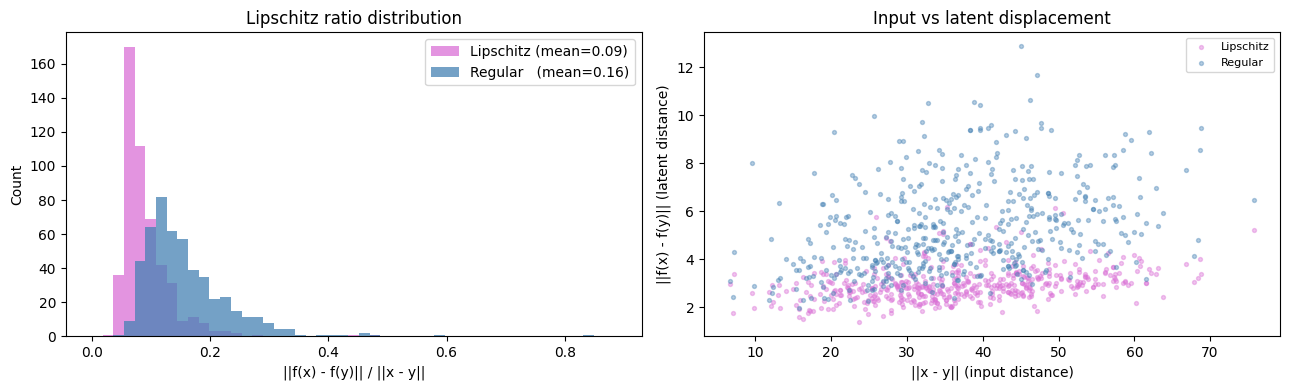

In [6]:
N_PAIRS = 500

# enc_lip and enc_reg are defined in the spectral norm cell above
idx_a = torch.randint(len(x_test), (N_PAIRS,))
idx_b = torch.randint(len(x_test), (N_PAIRS,))
x_a   = x_test[idx_a].to(device)
x_b   = x_test[idx_b].to(device)

with torch.no_grad():
    z_a_lip, z_b_lip = enc_lip(x_a), enc_lip(x_b)
    z_a_reg, z_b_reg = enc_reg(x_a), enc_reg(x_b)

dx        = (x_a - x_b).norm(dim=1).cpu().numpy()
dz_lip    = (z_a_lip - z_b_lip).norm(dim=1).cpu().numpy()
dz_reg    = (z_a_reg - z_b_reg).norm(dim=1).cpu().numpy()
ratio_lip = dz_lip / (dx + 1e-12)
ratio_reg = dz_reg / (dx + 1e-12)

print(f"Lipschitz ratio ||f(x)-f(y)|| / ||x-y|| over {N_PAIRS} pairs:")
print(f"  Lipschitz  mean={ratio_lip.mean():.3f}  median={np.median(ratio_lip):.3f}  "
      f"95th={np.percentile(ratio_lip, 95):.3f}  max={ratio_lip.max():.3f}")
print(f"  Regular    mean={ratio_reg.mean():.3f}  median={np.median(ratio_reg):.3f}  "
      f"95th={np.percentile(ratio_reg, 95):.3f}  max={ratio_reg.max():.3f}")

bins = np.linspace(0, max(ratio_lip.max(), ratio_reg.max()) * 1.05, 50)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(ratio_lip, bins=bins, color='orchid',    alpha=0.75, label=f'Lipschitz (mean={ratio_lip.mean():.2f})')
ax.hist(ratio_reg, bins=bins, color='steelblue', alpha=0.75, label=f'Regular   (mean={ratio_reg.mean():.2f})')
ax.set_xlabel('||f(x) - f(y)|| / ||x - y||')
ax.set_ylabel('Count')
ax.set_title('Lipschitz ratio distribution')
ax.legend()

ax = axes[1]
ax.scatter(dx, dz_lip, s=8, alpha=0.4, color='orchid',    label='Lipschitz')
ax.scatter(dx, dz_reg, s=8, alpha=0.4, color='steelblue', label='Regular')
ax.set_xlabel('||x - y|| (input distance)')
ax.set_ylabel('||f(x) - f(y)|| (latent distance)')
ax.set_title('Input vs latent displacement')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Embedding diagnostics + spectral norm check

In [7]:
emb_net = posterior.posterior_estimator.embedding_net

with torch.no_grad():
    emb_out = emb_net(x_test[:64].to(device))
print(f'Embedding output shape: {emb_out.shape}')  # expect (64, 128)
print(f'Per-dim std  min/mean/max: '
      f'{emb_out.std(0).min():.4f} / {emb_out.std(0).mean():.4f} / {emb_out.std(0).max():.4f}')
print(f'Overall mean: {emb_out.mean():.4f}  std: {emb_out.std():.4f}')

# Spectral norm diagnostics — parametrizations are removed at save time (weights are baked in),
# so we compute sigma_1 directly via power iteration on the baked weight matrices.
print(f'\nSpectral norms of baked weights (ceiling was 2.0 during training):')
import torch.nn.functional as F
for name, mod in emb_net.named_modules():
    if not hasattr(mod, 'weight'): continue
    W = mod.weight.detach().reshape(mod.weight.shape[0], -1)
    u = F.normalize(torch.randn(W.shape[0], device=W.device), dim=0)
    for _ in range(20):
        v = F.normalize(W.t() @ u, dim=0)
        u = F.normalize(W @ v, dim=0)
    sigma = (u @ (W @ v)).item()
    flag = '  *** above ceiling' if sigma > 2.05 else ''
    print(f'  {name:<30} sigma={sigma:.4f}{flag}')

train_manifest = json.load(open(MANIFEST.parent / 'manifest_train.json'))
train_data_dir = '/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314/train'
ds_tr = ReducedCVDataset(train_data_dir, train_manifest['index'][:1], stats)
theta_tr, x_tr = ds_tr[0]
ds_tr.close()

with torch.no_grad():
    samples_tr = posterior.sample((500,), x=x_tr.to(device), show_progress_bars=False)
post_mean_tr = samples_tr.mean(0).cpu()

print(f"\nTraining obs sanity check:")
print(f"  {'param':<14} {'GT':>10} {'post mean':>12} {'err%':>8}")
for i, name in enumerate(PARAM_KEYS_INFER):
    err = abs(post_mean_tr[i].item() - theta_tr[i].item()) / (abs(theta_tr[i].item()) + 1e-9) * 100
    print(f"  {name:<14} {theta_tr[i].item():>10.4f} {post_mean_tr[i].item():>12.4f} {err:>7.1f}%")

Embedding output shape: torch.Size([64, 128])
Per-dim std  min/mean/max: 0.0434 / 0.1723 / 0.5390
Overall mean: 0.0193  std: 0.2122

Spectral norms of baked weights (ceiling was 2.0 during training):
  cnn.0                          sigma=2.0023
  cnn.2                          sigma=2.0041
  cnn.4                          sigma=2.0004
  cnn.6                          sigma=1.9986
  scalar_projs.0                 sigma=2.0000
  scalar_projs.1                 sigma=2.0000
  scalar_projs.2                 sigma=2.0000
  scalar_projs.3                 sigma=2.0000
  scalar_projs.4                 sigma=2.0000
  attn_pool                      sigma=1.4812
  proj                           sigma=1.9954

Training obs sanity check:
  param                  GT    post mean     err%
  AVD              278.7117     241.8771    13.2%
  Bla                0.0598       0.0620     3.6%
  Blv                0.0211       0.0327    55.5%
  Bra                0.0664       0.0532    19.8%
  Brv           

## Sample posterior for each test observation

In [8]:
all_means, all_q05, all_q95 = [], [], []

for i, x_o in enumerate(x_test):
    samples = posterior.sample((N_POSTERIOR_SAMPLES,), x=x_o.to(device), show_progress_bars=False)
    all_means.append(samples.mean(dim=0).cpu())
    all_q05.append(samples.quantile(0.05, dim=0).cpu())
    all_q95.append(samples.quantile(0.95, dim=0).cpu())
    if (i + 1) % 50 == 0:
        print(f'  {i + 1}/{len(x_test)} done')

pred_mean = torch.stack(all_means).numpy()  # (256, 24)
q05       = torch.stack(all_q05).numpy()
q95       = torch.stack(all_q95).numpy()
gt_phys   = theta_gt.numpy()

print(f'Posterior mean shape: {pred_mean.shape}')

  50/256 done
  100/256 done
  150/256 done
  200/256 done
  250/256 done
Posterior mean shape: (256, 24)


## Point-estimate metrics

In [9]:
abs_err = np.abs(pred_mean - gt_phys)
ch_mae  = abs_err.mean(axis=0)
ch_med  = np.median(abs_err, axis=0)
ch_mape = (abs_err / (np.abs(gt_phys) + 1e-9) * 100).mean(axis=0)

print(f"{'Parameter':<14} {'MAE':>12} {'Median AE':>12} {'MAPE (%)':>10}")
print('-' * 52)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f'{name:<14} {ch_mae[i]:>12.4f} {ch_med[i]:>12.4f} {ch_mape[i]:>10.2f}%')

print(f'\nOverall  MAE (mean): {ch_mae.mean():.4f}  MAPE: {ch_mape.mean():.2f}%')

Parameter               MAE    Median AE   MAPE (%)
----------------------------------------------------
AVD                 15.7481      10.0931      10.44%
Bla                  0.0199       0.0174      35.12%
Blv                  0.0082       0.0074      25.11%
Bra                  0.0088       0.0060      17.76%
Brv                  0.0029       0.0017       8.03%
Cas                  0.0190       0.0128       1.49%
Cvp                  0.5958       0.4170      15.81%
Cvs                 20.6552      20.4248      35.46%
Eap                  0.0250       0.0067       1.70%
Eedref_la            0.4975       0.4404     100.99%
Eedref_lv            0.3872       0.3389     106.62%
Eedref_ra            0.1846       0.1272      67.23%
Eedref_rv            0.0781       0.0362      18.98%
Emax_LA              0.1225       0.0950      33.48%
Emax_LV              0.6992       0.5484      37.61%
Emax_RA              0.0852       0.0645      25.17%
Emax_RV              0.0290       0.0179       

In [10]:
post_mean_std = pred_mean.std(axis=0)
prior_range   = np.array([
    manifest['config']['pvar_high'][k] - manifest['config']['pvar_low'][k]
    for k in PARAM_KEYS_INFER
])
variation_pct = post_mean_std / prior_range * 100

print(f"{'param':<14} {'post-mean std':>14} {'prior range':>12} {'variation %':>12}")
print('-' * 55)
for i, name in enumerate(PARAM_KEYS_INFER):
    print(f"{name:<14} {post_mean_std[i]:>14.4f} {prior_range[i]:>12.4f} {variation_pct[i]:>11.1f}%")

print(f"\nMean variation across params: {variation_pct.mean():.1f}% of prior range")

param           post-mean std  prior range  variation %
-------------------------------------------------------
AVD                   63.1129     240.0000        26.3%
Bla                    0.0104       0.0900        11.5%
Blv                    0.0051       0.0400        12.8%
Bra                    0.0158       0.0700        22.6%
Brv                    0.0104       0.0400        26.0%
Cas                    0.7229       2.4500        29.5%
Cvp                    2.1329       8.0000        26.7%
Cvs                    7.3721      90.0000         8.2%
Eap                    1.4526       4.9700        29.2%
Eedref_la              0.3887       2.4000        16.2%
Eedref_lv              0.2745       1.9200        14.3%
Eedref_ra              0.3371       1.4700        22.9%
Eedref_rv              0.4021       1.4700        27.4%
Emax_LA                0.2024       0.9000        22.5%
Emax_LV                0.9046       4.5000        20.1%
Emax_RA                0.1548       0.7000      

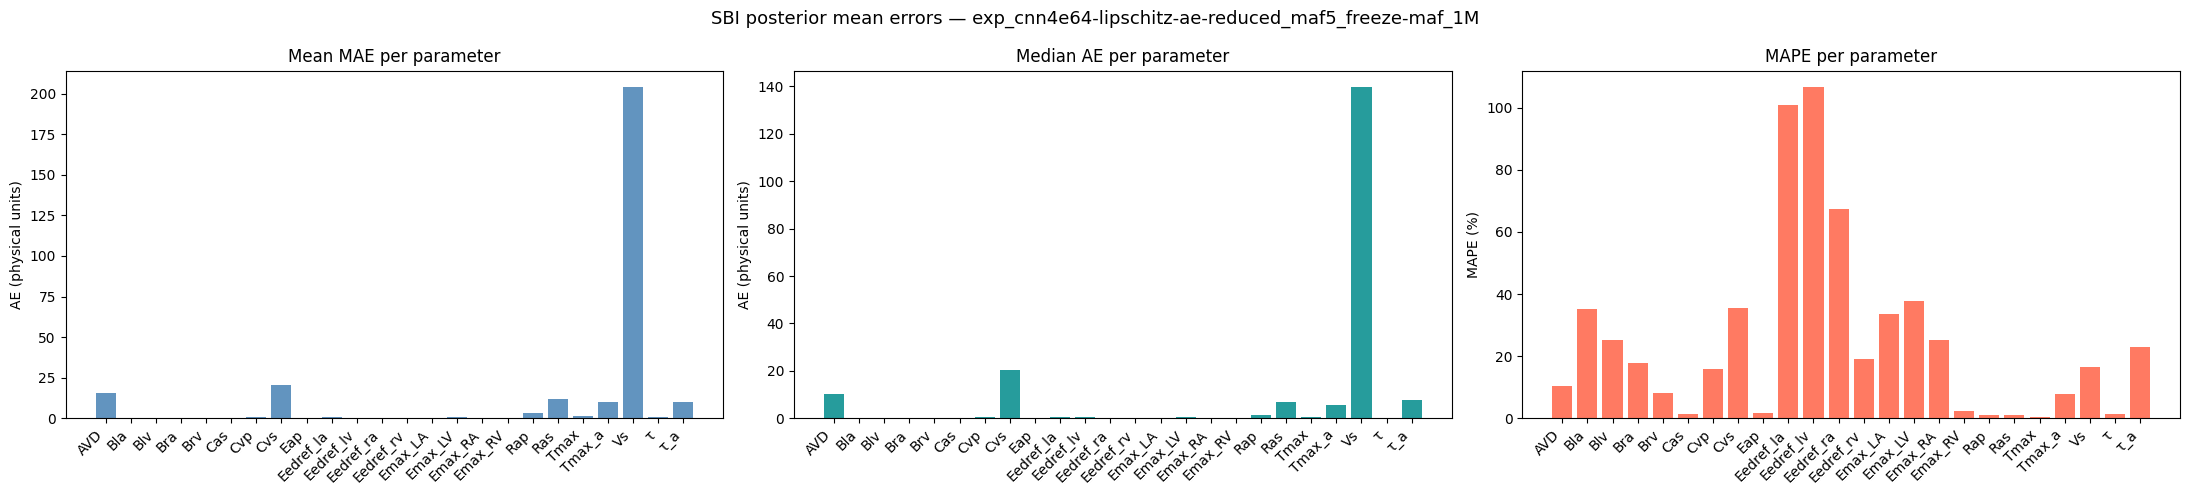

In [11]:
x_pos = np.arange(len(PARAM_KEYS_INFER))
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].bar(x_pos, ch_mae,  color='steelblue', alpha=0.85)
axes[1].bar(x_pos, ch_med,  color='darkcyan',  alpha=0.85)
axes[2].bar(x_pos, ch_mape, color='tomato',    alpha=0.85)

for ax, title, ylabel in zip(axes,
    ['Mean MAE per parameter', 'Median AE per parameter', 'MAPE per parameter'],
    ['AE (physical units)', 'AE (physical units)', 'MAPE (%)']):
    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)

fig.suptitle(f'SBI posterior mean errors \u2014 {RUN_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

## Predicted vs GT scatter — 24 parameters

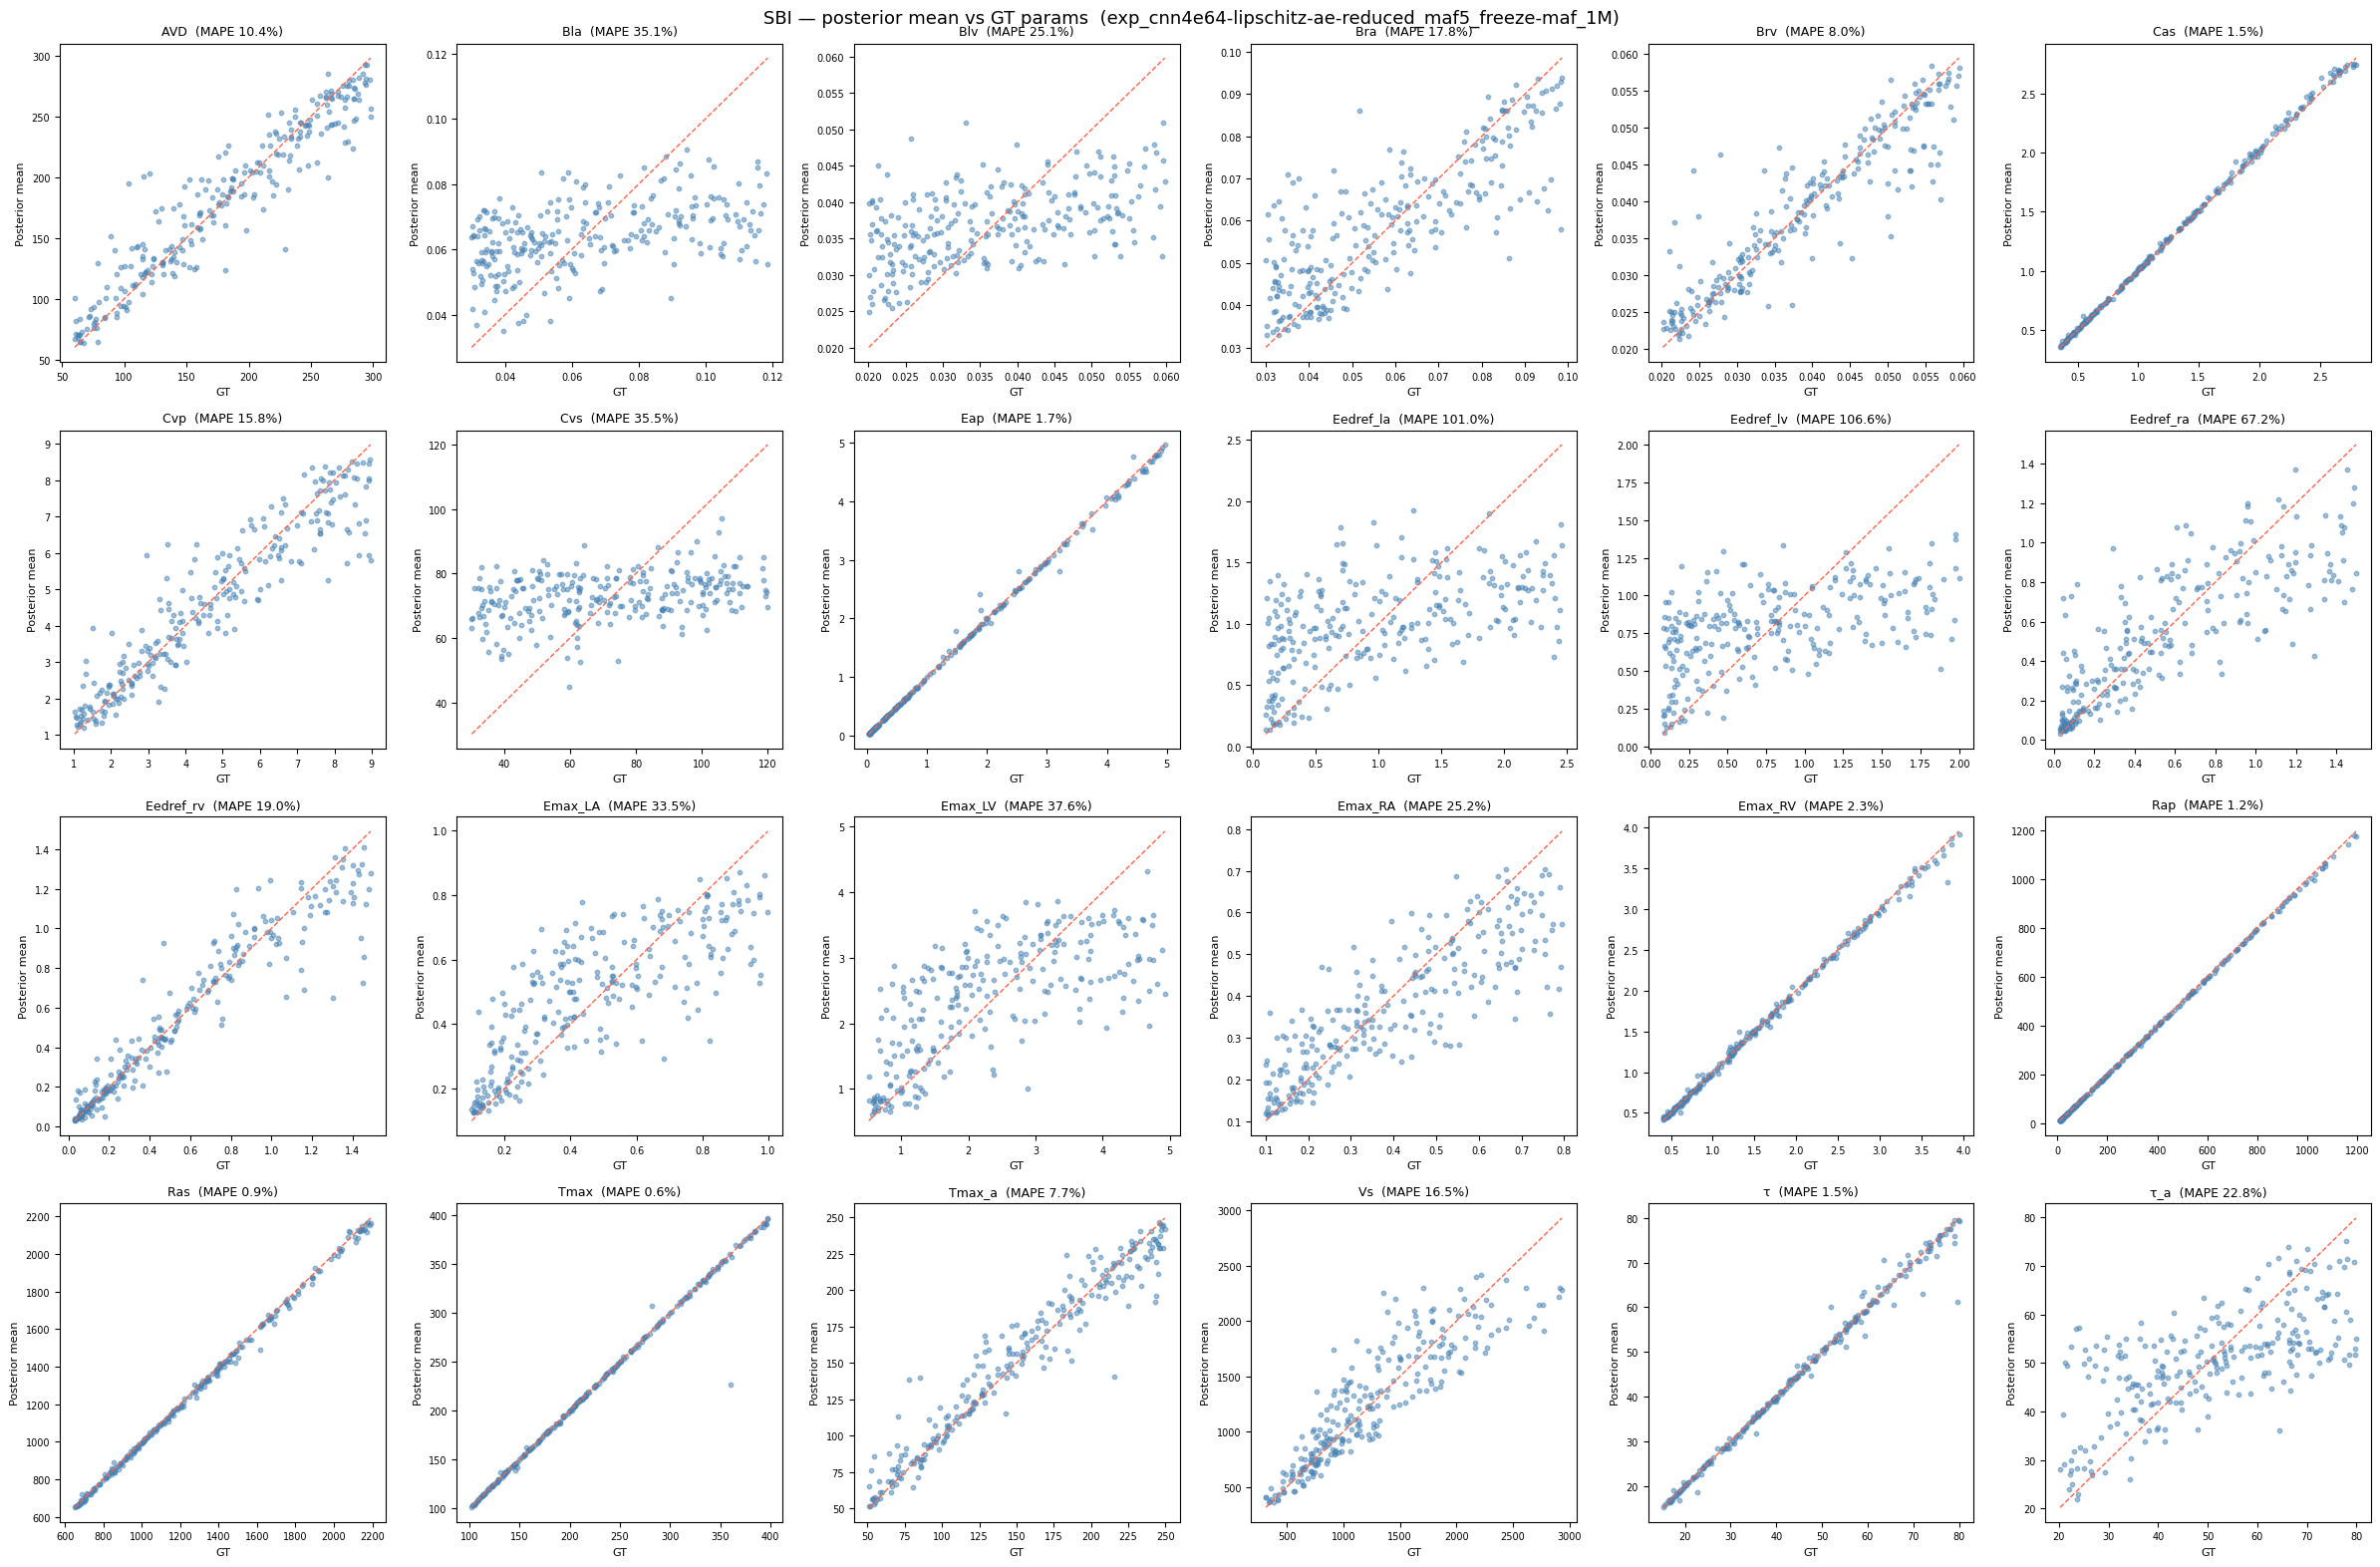

In [12]:
ncols, nrows = 6, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))

for i, name in enumerate(PARAM_KEYS_INFER):
    ax = axes[i // ncols, i % ncols]
    gt_i, pred_i = gt_phys[:, i], pred_mean[:, i]
    lo, hi = gt_i.min(), gt_i.max()
    ax.scatter(gt_i, pred_i, s=10, alpha=0.5, color='steelblue')
    ax.plot([lo, hi], [lo, hi], color='tomato', linewidth=1, linestyle='--')
    ax.set_title(f'{name}  (MAPE {ch_mape[i]:.1f}%)', fontsize=9)
    ax.set_xlabel('GT', fontsize=8)
    ax.set_ylabel('Posterior mean', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle(f'SBI \u2014 posterior mean vs GT params  ({RUN_NAME})', fontsize=13)
plt.tight_layout()
plt.show()

## 90% credible interval coverage

For a well-calibrated posterior, ~90% of GT values should fall inside the 90% CI.

In [13]:
in_ci    = (gt_phys >= q05) & (gt_phys <= q95)
coverage = in_ci.mean(axis=0) * 100

print(f"{'Parameter':<14} {'90% CI coverage':>18}")
print('-' * 35)
for i, name in enumerate(PARAM_KEYS_INFER):
    flag = '  \u2713' if 85 <= coverage[i] <= 95 else '  \u2190'
    print(f'{name:<14} {coverage[i]:>16.1f}%{flag}')

print(f'\nMean coverage: {coverage.mean():.1f}%  (target: 90%)')

Parameter         90% CI coverage
-----------------------------------
AVD                        82.8%  ←
Bla                        80.5%  ←
Blv                        80.1%  ←
Bra                        82.4%  ←
Brv                        89.5%  ✓
Cas                        94.1%  ✓
Cvp                        82.0%  ←
Cvs                        89.1%  ✓
Eap                        88.7%  ✓
Eedref_la                  83.2%  ←
Eedref_lv                  83.6%  ←
Eedref_ra                  80.9%  ←
Eedref_rv                  86.3%  ✓
Emax_LA                    87.9%  ✓
Emax_LV                    80.1%  ←
Emax_RA                    84.4%  ←
Emax_RV                    89.8%  ✓
Rap                        93.4%  ✓
Ras                        86.3%  ✓
Tmax                       93.4%  ✓
Tmax_a                     84.8%  ←
Vs                         85.9%  ✓
τ                          92.2%  ✓
τ_a                        85.9%  ✓

Mean coverage: 86.1%  (target: 90%)


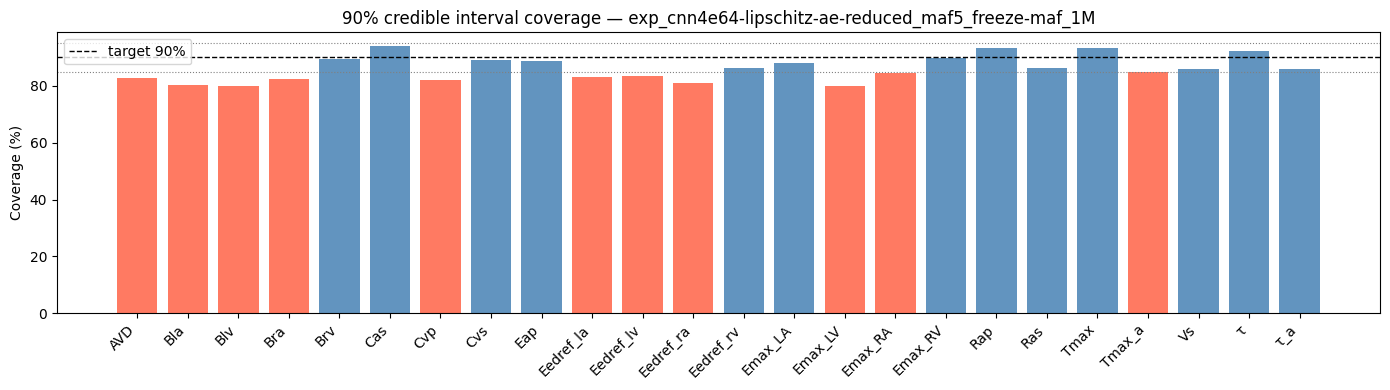

In [14]:
x_pos  = np.arange(len(PARAM_KEYS_INFER))
fig, ax = plt.subplots(figsize=(14, 4))
colors  = ['steelblue' if 85 <= c <= 95 else 'tomato' for c in coverage]
ax.bar(x_pos, coverage, color=colors, alpha=0.85)
ax.axhline(90, color='black', linestyle='--', linewidth=1, label='target 90%')
ax.axhline(85, color='gray',  linestyle=':',  linewidth=0.8)
ax.axhline(95, color='gray',  linestyle=':',  linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_KEYS_INFER, rotation=45, ha='right')
ax.set_ylabel('Coverage (%)')
ax.set_title(f'90% credible interval coverage \u2014 {RUN_NAME}')
ax.legend()
plt.tight_layout()
plt.show()